# OULAD - Deep Learning Modeling

This notebook loads the tensor data and trains PyTorch models (LSTM/Transformer).

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
RANDOM_SEED = 42

# Cập nhật DATAPATH nếu cần (mặc định lấy từ thư mục seq_data)
DATAPATH = '/kaggle/input/notebooks/lnthuc/oulad-dl-01/'
SEQ_PATH = DATAPATH + 'seq_data/'

try:
    X_seq_train = np.load(SEQ_PATH + 'X_seq_train.npy')
    X_static_train = np.load(SEQ_PATH + 'X_static_train.npy')
    mask_train = np.load(SEQ_PATH + 'mask_train.npy')
    y_train = np.load(SEQ_PATH + 'y_train.npy')
    
    X_seq_test = np.load(SEQ_PATH + 'X_seq_test.npy')
    X_static_test = np.load(SEQ_PATH + 'X_static_test.npy')
    mask_test = np.load(SEQ_PATH + 'mask_test.npy')
    y_test = np.load(SEQ_PATH + 'y_test.npy')
    print("Loaded TENSOR formats successfully.")
    print("X_seq_train shape:", X_seq_train.shape)
except FileNotFoundError:
    print("Data not found! Please run Data Processing notebook first and adjust SEQ_PATH.")


Loaded TENSOR formats successfully.
X_seq_train shape: (21333, 34, 33)


In [2]:
import json

try:
    with open(SEQ_PATH + 'feature_cols_detail.json', 'r') as f:
        meta = json.load(f)
    DYNAMIC_FEATURES = meta['dynamic_features']
    STATIC_FEATURES = meta['static_features']
    print(f"Found {len(DYNAMIC_FEATURES)} dynamic features and {len(STATIC_FEATURES)} static features.")
    
    # Slice the loaded sequence and static tensors to match the active features
    try:
        with open(SEQ_PATH + 'feature_meta.json', 'r') as f_meta:
            meta_orig = json.load(f_meta)
        orig_dynamic = meta_orig['DYNAMIC_FEATURES']
        orig_static = meta_orig['STATIC_FEATURES']
        
        dynamic_indices = [orig_dynamic.index(col) for col in DYNAMIC_FEATURES if col in orig_dynamic]
        static_indices = [orig_static.index(col) for col in STATIC_FEATURES if col in orig_static]
        
        if 'X_seq_train' in locals() and X_seq_train is not None:
            print("Original X_seq_train shape:", X_seq_train.shape)
            X_seq_train = X_seq_train[:, :, dynamic_indices]
            X_seq_test = X_seq_test[:, :, dynamic_indices]
            print("Sliced X_seq_train shape to active features:", X_seq_train.shape)
            
        if 'X_static_train' in locals() and X_static_train is not None:
            print("Original X_static_train shape:", X_static_train.shape)
            X_static_train = X_static_train[:, static_indices]
            X_static_test = X_static_test[:, static_indices]
            print("Sliced X_static_train shape to active features:", X_static_train.shape)
    except Exception as e:
        print("Error during tensor slicing (perhaps feature_meta.json not found):", e)
except Exception as e:
    print("Could not load feature columns metadata:", e)
    # Fallback to counts if metadata is missing (based on original array shapes)
    # 33 dynamic, 25 static

# Define T_MAX from sequence length
if 'X_seq_train' in locals():
    T_MAX = X_seq_train.shape[1]


Found 22 dynamic features and 20 static features.
Original X_seq_train shape: (21333, 34, 33)
Sliced X_seq_train shape to active features: (21333, 34, 22)
Original X_static_train shape: (21333, 25)
Sliced X_static_train shape to active features: (21333, 20)


## 5. PyTorch Dataset — Random-Truncation Training

Muc dich **realtime EWS**: model phai predict duoc o **bat ky tuan `t` nao** trong `[t_min, T_MAX-1]`.

**Random-truncation training:** moi sample moi epoch random mot `t` trong `[4, T_MAX-1]`, mask het cac tuan `> t`, predict target. Nhu vay model hoc predict deu o moi tuan.

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

class OULADSeqDataset(Dataset):
    def __init__(self, X_seq, X_static, mask, y, random_trunc=True, t_min=4, fixed_t=None):
        self.X_seq    = torch.from_numpy(X_seq).float()
        self.X_static = torch.from_numpy(X_static).float()
        self.mask     = torch.from_numpy(mask).bool()
        self.y        = torch.from_numpy(y).float()
        self.T = X_seq.shape[1]
        self.random_trunc = random_trunc
        self.t_min = t_min
        self.fixed_t = fixed_t

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        seq    = self.X_seq[idx]
        static = self.X_static[idx]
        mask   = self.mask[idx].clone()
        y      = self.y[idx]

        if self.fixed_t is not None:
            t = self.fixed_t
        elif self.random_trunc:
            t = torch.randint(self.t_min, self.T, (1,)).item()
        else:
            t = self.T - 1

        if t < self.T - 1:
            mask[t+1:] = True

        return seq, static, mask, y, t

print('Dataset class ready.')

Device: cuda
Dataset class ready.


## 6. LSTM Model

In [4]:
class EWSLSTM(nn.Module):
    def __init__(self, n_dynamic, n_static, hidden=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_dynamic, hidden_size=hidden,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.static_proj = nn.Sequential(
            nn.Linear(n_static, hidden), nn.ReLU(), nn.Dropout(dropout)
        )
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )

    def forward(self, x_seq, x_static, mask):
        out, _ = self.lstm(x_seq)
        lengths = (~mask).sum(dim=1).clamp(min=1) - 1
        idx = lengths.view(-1, 1, 1).expand(-1, 1, out.size(-1))
        h_last = out.gather(1, idx).squeeze(1)
        s = self.static_proj(x_static)
        logits = self.head(torch.cat([h_last, s], dim=1)).squeeze(-1)
        return logits

model_lstm_check = EWSLSTM(len(DYNAMIC_FEATURES), len(STATIC_FEATURES))
print(model_lstm_check)
print(f'Params: {sum(p.numel() for p in model_lstm_check.parameters()):,}')

EWSLSTM(
  (lstm): LSTM(22, 64, num_layers=2, batch_first=True, dropout=0.3)
  (static_proj): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)
Params: 65,473


## 7. Transformer Model

In [5]:
class EWSTransformer(nn.Module):
    def __init__(self, n_dynamic, n_static, d_model=64, nhead=4, nlayers=2,
                 dropout=0.3, max_len=64):
        super().__init__()
        self.input_proj = nn.Linear(n_dynamic, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=nlayers)
        self.static_proj = nn.Sequential(
            nn.Linear(n_static, d_model), nn.ReLU(), nn.Dropout(dropout)
        )
        self.head = nn.Sequential(
            nn.Linear(d_model * 2, d_model), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_model, 1)
        )

    def forward(self, x_seq, x_static, mask):
        B, T, _ = x_seq.shape
        pos = torch.arange(T, device=x_seq.device).unsqueeze(0).expand(B, T)
        h = self.input_proj(x_seq) + self.pos_emb(pos)
        h = self.encoder(h, src_key_padding_mask=mask)
        lengths = (~mask).sum(dim=1).clamp(min=1) - 1
        idx = lengths.view(-1, 1, 1).expand(-1, 1, h.size(-1))
        h_last = h.gather(1, idx).squeeze(1)
        s = self.static_proj(x_static)
        logits = self.head(torch.cat([h_last, s], dim=1)).squeeze(-1)
        return logits

model_tr_check = EWSTransformer(len(DYNAMIC_FEATURES), len(STATIC_FEATURES))
print(model_tr_check)
print(f'Params: {sum(p.numel() for p in model_tr_check.parameters()):,}')

EWSTransformer(
  (input_proj): Linear(in_features=22, out_features=64, bias=True)
  (pos_emb): Embedding(64, 64)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (static_proj): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (head): Sequential(
    (0): Linear(i

## 8. Training Loop + Realtime Evaluation

**Eval:** sau khi train, danh gia model o cac checkpoint tuan co dinh: 4, 8, 12, 16, 20, 24.
Moi tuan `t` -> tao dataset voi `fixed_t=t` -> predict -> metric.
Neu metric tang dan theo `t` thi model dung nghia "realtime EWS": cang nhieu info cang predict tot.

In [6]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score)

def train_model(model, X_seq_tr, X_st_tr, mask_tr, y_tr,
                X_seq_va, X_st_va, mask_va, y_va,
                epochs=25, batch_size=256, lr=1e-3,
                t_min=4, pos_weight=None, verbose=True):
    model = model.to(device)

    train_ds = OULADSeqDataset(X_seq_tr, X_st_tr, mask_tr, y_tr,
                               random_trunc=True, t_min=t_min)
    val_ds   = OULADSeqDataset(X_seq_va, X_st_va, mask_va, y_va,
                               random_trunc=False)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)

    if pos_weight is None:
        pos = y_tr.sum()
        neg = len(y_tr) - pos
        pos_weight = torch.tensor([neg / max(pos,1)], dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=epochs)

    history = []
    best_auc = 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        tot_loss = 0
        n = 0
        for seq, static, mask, y, t in train_loader:
            seq, static, mask, y = seq.to(device), static.to(device), mask.to(device), y.to(device)
            optim.zero_grad()
            logits = model(seq, static, mask)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim.step()
            tot_loss += loss.item() * len(y)
            n += len(y)
        sched.step()

        model.eval()
        all_p, all_y = [], []
        with torch.no_grad():
            for seq, static, mask, y, t in val_loader:
                seq, static, mask = seq.to(device), static.to(device), mask.to(device)
                logits = model(seq, static, mask)
                all_p.append(torch.sigmoid(logits).cpu().numpy())
                all_y.append(y.numpy())
        all_p = np.concatenate(all_p)
        all_y = np.concatenate(all_y)
        auc = roc_auc_score(all_y, all_p)
        f1  = f1_score(all_y, (all_p > 0.5).astype(int))

        history.append({'epoch': epoch, 'train_loss': tot_loss / n, 'val_auc': auc, 'val_f1': f1})
        if verbose:
            print(f'Ep {epoch+1:02d} | loss={tot_loss/n:.4f} | val_auc={auc:.4f} | val_f1={f1:.4f}')

        if auc > best_auc:
            best_auc = auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history

print('train_model ready.')

train_model ready.


In [7]:
def eval_at_weeks(model, X_seq, X_static, mask, y, weeks=None, batch_size=256):
    """Danh gia model o cac checkpoint tuan co dinh."""
    if weeks is None:
        weeks = list(range(0, X_seq.shape[1]))
    results = []
    model.eval()
    for t in weeks:
        if t >= X_seq.shape[1]:
            continue
        ds = OULADSeqDataset(X_seq, X_static, mask, y, random_trunc=False, fixed_t=t)
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
        all_p, all_y = [], []
        with torch.no_grad():
            for seq, static, m, yy, _ in loader:
                seq, static, m = seq.to(device), static.to(device), m.to(device)
                logits = model(seq, static, m)
                all_p.append(torch.sigmoid(logits).cpu().numpy())
                all_y.append(yy.numpy())
        all_p = np.concatenate(all_p); all_y = np.concatenate(all_y)
        pred = (all_p > 0.5).astype(int)
        results.append({
            'week': t,
            'auc':       roc_auc_score(all_y, all_p),
            'accuracy':  accuracy_score(all_y, pred),
            'precision': precision_score(all_y, pred, zero_division=0),
            'recall':    recall_score(all_y, pred, zero_division=0),
            'f1':        f1_score(all_y, pred, zero_division=0),
        })
    return pd.DataFrame(results)

print('eval_at_weeks ready.')

eval_at_weeks ready.


In [8]:
# 8.1 Train LSTM
torch.manual_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
model_lstm = EWSLSTM(len(DYNAMIC_FEATURES), len(STATIC_FEATURES),
                     hidden=64, num_layers=2, dropout=0.3)
model_lstm, hist_lstm = train_model(
    model_lstm, X_seq_train, X_static_train, mask_train, y_train,
    X_seq_test, X_static_test, mask_test, y_test,
    epochs=25, batch_size=256, lr=1e-3, t_min=4
)

Ep 01 | loss=0.4049 | val_auc=0.9732 | val_f1=0.9225
Ep 02 | loss=0.2956 | val_auc=0.9759 | val_f1=0.9244
Ep 03 | loss=0.2855 | val_auc=0.9774 | val_f1=0.9282
Ep 04 | loss=0.2806 | val_auc=0.9782 | val_f1=0.9315
Ep 05 | loss=0.2765 | val_auc=0.9793 | val_f1=0.9319
Ep 06 | loss=0.2763 | val_auc=0.9797 | val_f1=0.9339
Ep 07 | loss=0.2698 | val_auc=0.9797 | val_f1=0.9300
Ep 08 | loss=0.2724 | val_auc=0.9796 | val_f1=0.9317
Ep 09 | loss=0.2656 | val_auc=0.9804 | val_f1=0.9325
Ep 10 | loss=0.2676 | val_auc=0.9799 | val_f1=0.9310
Ep 11 | loss=0.2650 | val_auc=0.9803 | val_f1=0.9308
Ep 12 | loss=0.2647 | val_auc=0.9802 | val_f1=0.9305
Ep 13 | loss=0.2628 | val_auc=0.9798 | val_f1=0.9312
Ep 14 | loss=0.2639 | val_auc=0.9798 | val_f1=0.9313
Ep 15 | loss=0.2684 | val_auc=0.9800 | val_f1=0.9315
Ep 16 | loss=0.2653 | val_auc=0.9802 | val_f1=0.9318
Ep 17 | loss=0.2633 | val_auc=0.9807 | val_f1=0.9319
Ep 18 | loss=0.2591 | val_auc=0.9808 | val_f1=0.9322
Ep 19 | loss=0.2610 | val_auc=0.9805 | val_f1=

In [9]:
# 8.2 Evaluate LSTM o cac checkpoint tuan
res_lstm = eval_at_weeks(model_lstm, X_seq_test, X_static_test, mask_test, y_test)
print('LSTM realtime performance:')
print(res_lstm.round(4))

LSTM realtime performance:
    week     auc  accuracy  precision  recall      f1
0      0  0.7018    0.6150     0.7064  0.4329  0.5368
1      1  0.7489    0.6665     0.7750  0.4973  0.6059
2      2  0.7617    0.6705     0.7866  0.4949  0.6076
3      3  0.7819    0.6874     0.7992  0.5254  0.6340
4      4  0.8094    0.7179     0.8177  0.5826  0.6804
5      5  0.8239    0.7323     0.8288  0.6057  0.6999
6      6  0.8373    0.7456     0.8439  0.6214  0.7158
7      7  0.8600    0.7614     0.8697  0.6316  0.7318
8      8  0.8749    0.7745     0.8873  0.6443  0.7465
9      9  0.8840    0.7891     0.9042  0.6607  0.7635
10    10  0.8890    0.8003     0.8981  0.6908  0.7809
11    11  0.8915    0.8068     0.8840  0.7196  0.7934
12    12  0.8983    0.8138     0.8880  0.7308  0.8018
13    13  0.9079    0.8259     0.9079  0.7370  0.8136
14    14  0.9141    0.8304     0.9139  0.7407  0.8182
15    15  0.9240    0.8431     0.9412  0.7419  0.8297
16    16  0.9299    0.8535     0.9468  0.7582  0.8421
1

In [10]:
# 8.3 Train Transformer
torch.manual_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
model_tr = EWSTransformer(len(DYNAMIC_FEATURES), len(STATIC_FEATURES),
                          d_model=64, nhead=4, nlayers=2, dropout=0.3,
                          max_len=T_MAX + 8)
model_tr, hist_tr = train_model(
    model_tr, X_seq_train, X_static_train, mask_train, y_train,
    X_seq_test, X_static_test, mask_test, y_test,
    epochs=25, batch_size=256, lr=1e-3, t_min=4
)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Ep 01 | loss=0.3856 | val_auc=0.9694 | val_f1=0.9075
Ep 02 | loss=0.3127 | val_auc=0.9744 | val_f1=0.9247
Ep 03 | loss=0.2992 | val_auc=0.9732 | val_f1=0.9216
Ep 04 | loss=0.2927 | val_auc=0.9771 | val_f1=0.9305
Ep 05 | loss=0.2892 | val_auc=0.9758 | val_f1=0.9236
Ep 06 | loss=0.2835 | val_auc=0.9766 | val_f1=0.9257
Ep 07 | loss=0.2835 | val_auc=0.9763 | val_f1=0.9256
Ep 08 | loss=0.2807 | val_auc=0.9773 | val_f1=0.9260
Ep 09 | loss=0.2750 | val_auc=0.9780 | val_f1=0.9295
Ep 10 | loss=0.2734 | val_auc=0.9773 | val_f1=0.9260
Ep 11 | loss=0.2745 | val_auc=0.9784 | val_f1=0.9297
Ep 12 | loss=0.2714 | val_auc=0.9782 | val_f1=0.9312
Ep 13 | loss=0.2731 | val_auc=0.9787 | val_f1=0.9326
Ep 14 | loss=0.2681 | val_auc=0.9786 | val_f1=0.9338
Ep 15 | loss=0.2697 | val_auc=0.9787 | val_f1=0.9314
Ep 16 | loss=0.2658 | val_auc=0.9788 | val_f1=0.9308
Ep 17 | loss=0.2644 | val_auc=0.9788 | val_f1=0.9289
Ep 18 | loss=0.2657 | val_auc=0.9788 | val_f1=0.9254
Ep 19 | loss=0.2630 | val_auc=0.9793 | val_f1=

In [11]:
# 8.4 Evaluate Transformer
res_tr = eval_at_weeks(model_tr, X_seq_test, X_static_test, mask_test, y_test)
print('Transformer realtime performance:')
print(res_tr.round(4))

Transformer realtime performance:
    week     auc  accuracy  precision  recall      f1
0      0  0.7009    0.4850     1.0000  0.0007  0.0014
1      1  0.7074    0.4847     0.5128  0.0034  0.0068
2      2  0.7223    0.4864     0.6562  0.0072  0.0143
3      3  0.7558    0.5983     0.9097  0.2449  0.3859
4      4  0.8299    0.7337     0.8206  0.6186  0.7054
5      5  0.8388    0.7417     0.8328  0.6242  0.7136
6      6  0.8505    0.7490     0.8456  0.6276  0.7205
7      7  0.8691    0.7750     0.8595  0.6734  0.7552
8      8  0.8843    0.7983     0.8801  0.7046  0.7827
9      9  0.8895    0.8012     0.8886  0.7022  0.7845
10    10  0.8926    0.8050     0.8894  0.7098  0.7895
11    11  0.8935    0.8097     0.9081  0.7017  0.7917
12    12  0.9006    0.8120     0.8936  0.7210  0.7981
13    13  0.9097    0.8266     0.8916  0.7555  0.8179
14    14  0.9140    0.8311     0.9024  0.7537  0.8214
15    15  0.9274    0.8510     0.9123  0.7865  0.8447
16    16  0.9293    0.8541     0.9298  0.7755  0

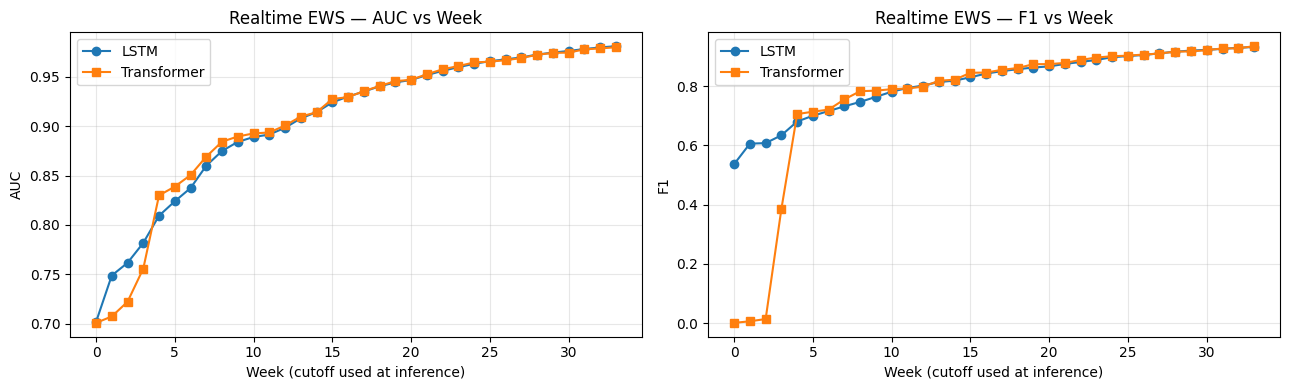

In [12]:
# 8.5 So sanh & ve
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13,4))
for ax, metric in zip(axes, ['auc','f1']):
    ax.plot(res_lstm['week'], res_lstm[metric], 'o-', label='LSTM')
    ax.plot(res_tr['week'],   res_tr[metric],   's-', label='Transformer')
    ax.set_xlabel('Week (cutoff used at inference)')
    ax.set_ylabel(metric.upper())
    ax.set_title(f'Realtime EWS — {metric.upper()} vs Week')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Hyperparameter Tuning with Optuna

Trong phần này, chúng ta sử dụng Optuna để dò tìm siêu tham số tối ưu cho mô hình. Mục tiêu là tối đa hoá **F1 Score** (như đề xuất, F1 phản ánh trực tiếp hiệu quả phân loại cuối cùng sau khi áp dụng ngưỡng 0.5, đặc biệt hữu ích khi cần chẩn đoán sớm). 
Chúng ta cũng áp dụng kỹ thuật **Pruning (MedianPruner)** để ngắt sớm các thử nghiệm kém hiệu quả, tiết kiệm tài nguyên trên GPU.

In [13]:
!pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


In [14]:
def train_model_optuna(model, X_seq_tr, X_st_tr, mask_tr, y_tr,
                       X_seq_va, X_st_va, mask_va, y_va,
                       epochs=25, batch_size=256, lr=1e-3,
                       t_min=4, pos_weight=None, verbose=False, trial=None):
    model = model.to(device)

    train_ds = OULADSeqDataset(X_seq_tr, X_st_tr, mask_tr, y_tr,
                               random_trunc=True, t_min=t_min)
    val_ds   = OULADSeqDataset(X_seq_va, X_st_va, mask_va, y_va,
                               random_trunc=False)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)

    if pos_weight is None:
        pos = y_tr.sum()
        neg = len(y_tr) - pos
        pos_weight = torch.tensor([neg / max(pos,1)], dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=epochs)

    best_f1 = 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        for seq, static, mask, y, t in train_loader:
            seq, static, mask, y = seq.to(device), static.to(device), mask.to(device), y.to(device)
            optim.zero_grad()
            logits = model(seq, static, mask)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim.step()
        sched.step()

        model.eval()
        val_f1_list = []
        for check_t in [4, 8, 12, 16, 20, 24]:
            if check_t >= X_seq_va.shape[1]: continue
            val_ds.fixed_t = check_t
            
            all_p, all_y = [], []
            with torch.no_grad():
                for seq, static, mask, y, t in val_loader:
                    seq, static, mask = seq.to(device), static.to(device), mask.to(device)
                    logits = model(seq, static, mask)
                    all_p.append(torch.sigmoid(logits).cpu().numpy())
                    all_y.append(y.numpy())
            all_p = np.concatenate(all_p)
            all_y = np.concatenate(all_y)
            f1_t = f1_score(all_y, (all_p > 0.5).astype(int))
            val_f1_list.append(f1_t)
            
        f1 = np.mean(val_f1_list) # Evaluate average Realtime performance
        
        if verbose:
            print(f"Epoch {epoch+1}/{epochs} - val_f1_mean: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        # Tích hợp Pruning của Optuna
        if trial is not None:
            trial.report(f1, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

    if best_state is not None:
        model.load_state_dict(best_state)
        
    return best_f1


In [15]:
def objective_lstm(trial):
    hidden = trial.suggest_categorical("hidden", [32, 64, 128])
    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    
    model = EWSLSTM(len(DYNAMIC_FEATURES), len(STATIC_FEATURES),
                     hidden=hidden, num_layers=num_layers, dropout=dropout)
    
    best_f1 = train_model_optuna(
        model, X_seq_train, X_static_train, mask_train, y_train,
        X_seq_test, X_static_test, mask_test, y_test,
        epochs=25, batch_size=256, lr=lr, t_min=4, trial=trial, verbose=False
    )
    return best_f1


In [16]:
study_lstm = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner(n_warmup_steps=5))
study_lstm.enqueue_trial({"hidden": 64, "num_layers": 2, "dropout": 0.3, "lr": 1e-3})
study_lstm.optimize(objective_lstm, n_trials=50) # Set 50 trials for Kaggle environment
print("Best LSTM parameters:", study_lstm.best_params)
print("Best LSTM F1:", study_lstm.best_value)


Best LSTM parameters: {'hidden': 128, 'num_layers': 3, 'dropout': 0.27484928516311946, 'lr': 0.002061151231200805}
Best LSTM F1: 0.8257125621709515


In [17]:
def objective_tr(trial):
    d_model = trial.suggest_categorical("d_model", [32, 64, 128])
    nlayers = trial.suggest_int("nlayers", 1, 3)
    nhead = trial.suggest_categorical("nhead", [2, 4, 8])
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    
    model = EWSTransformer(len(DYNAMIC_FEATURES), len(STATIC_FEATURES),
                           d_model=d_model, nhead=nhead, nlayers=nlayers, dropout=dropout,
                           max_len=X_seq_train.shape[1] + 8)
    
    best_f1 = train_model_optuna(
        model, X_seq_train, X_static_train, mask_train, y_train,
        X_seq_test, X_static_test, mask_test, y_test,
        epochs=25, batch_size=256, lr=lr, t_min=4, trial=trial, verbose=False
    )
    return best_f1


In [18]:
study_tr = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner(n_warmup_steps=5))
study_tr.enqueue_trial({"d_model": 64, "nhead": 4, "nlayers": 2, "dropout": 0.3, "lr": 1e-3})
study_tr.optimize(objective_tr, n_trials=50) # Set 50 trials
print("Best Transformer parameters:", study_tr.best_params)
print("Best Transformer F1:", study_tr.best_value)


Best Transformer parameters: {'d_model': 128, 'nlayers': 3, 'nhead': 8, 'dropout': 0.3180512392857705, 'lr': 0.0004755963713403883}
Best Transformer F1: 0.8284832345853919


## 10. Huấn luyện lại với Tham Số Tốt Nhất & Lưu Mô Hình

Sau khi Optuna tìm ra bộ tham số tốt nhất, chúng ta sẽ tự động sử dụng bộ tham số đó để khởi tạo và huấn luyện mô hình một lần nữa. Sau đó, mô hình sẽ được lưu xuống ổ đĩa (định dạng `.pth` chuẩn của PyTorch) để có thể tái sử dụng (Inference) mà không cần train lại.

In [19]:
# 10.1 Retrain LSTM với Best Params
print("Retraining LSTM with Best Params...")
best_lstm_params = study_lstm.best_params
best_lstm_model = EWSLSTM(len(DYNAMIC_FEATURES), len(STATIC_FEATURES),
                          hidden=best_lstm_params['hidden'], 
                          num_layers=best_lstm_params['num_layers'], 
                          dropout=best_lstm_params['dropout'])

# Lưu ý: Không truyền `trial` vào đây vì chúng ta muốn train hết số epoch
best_f1_lstm = train_model_optuna(
    best_lstm_model, X_seq_train, X_static_train, mask_train, y_train,
    X_seq_test, X_static_test, mask_test, y_test,
    epochs=25, batch_size=256, lr=best_lstm_params['lr'], t_min=4, verbose=True
)

# Đánh giá mô hình cuối cùng
res_lstm_best = eval_at_weeks(best_lstm_model, X_seq_test, X_static_test, mask_test, y_test)
print('\nLSTM Best Realtime Performance:')
print(res_lstm_best.round(4))

# Lưu mô hình
import os
import json
os.makedirs('/kaggle/working/models', exist_ok=True)
torch.save(best_lstm_model.state_dict(), '/kaggle/working/models/best_lstm_model.pth')
with open('/kaggle/working/models/best_lstm_params.json', 'w') as f:
    json.dump(best_lstm_params, f, indent=2)
print("\nĐã lưu LSTM model vào /kaggle/working/models/best_lstm_model.pth")


Retraining LSTM with Best Params...
Epoch 1/25 - val_f1_mean: 0.8089
Epoch 2/25 - val_f1_mean: 0.7972
Epoch 3/25 - val_f1_mean: 0.8113
Epoch 4/25 - val_f1_mean: 0.8161
Epoch 5/25 - val_f1_mean: 0.7935
Epoch 6/25 - val_f1_mean: 0.8144
Epoch 7/25 - val_f1_mean: 0.8101
Epoch 8/25 - val_f1_mean: 0.8026
Epoch 9/25 - val_f1_mean: 0.8094
Epoch 10/25 - val_f1_mean: 0.8095
Epoch 11/25 - val_f1_mean: 0.8176
Epoch 12/25 - val_f1_mean: 0.7942
Epoch 13/25 - val_f1_mean: 0.8021
Epoch 14/25 - val_f1_mean: 0.8091
Epoch 15/25 - val_f1_mean: 0.8002
Epoch 16/25 - val_f1_mean: 0.8041
Epoch 17/25 - val_f1_mean: 0.8002
Epoch 18/25 - val_f1_mean: 0.8098
Epoch 19/25 - val_f1_mean: 0.8074
Epoch 20/25 - val_f1_mean: 0.8046
Epoch 21/25 - val_f1_mean: 0.8068
Epoch 22/25 - val_f1_mean: 0.8070
Epoch 23/25 - val_f1_mean: 0.8050
Epoch 24/25 - val_f1_mean: 0.8045
Epoch 25/25 - val_f1_mean: 0.8049

LSTM Best Realtime Performance:
    week     auc  accuracy  precision  recall      f1
0      0  0.7088    0.6506     0.630

In [20]:
# 10.2 Retrain Transformer với Best Params
print("Retraining Transformer with Best Params...")
best_tr_params = study_tr.best_params
best_tr_model = EWSTransformer(len(DYNAMIC_FEATURES), len(STATIC_FEATURES),
                               d_model=best_tr_params['d_model'], 
                               nhead=best_tr_params['nhead'], 
                               nlayers=best_tr_params['nlayers'], 
                               dropout=best_tr_params['dropout'],
                               max_len=X_seq_train.shape[1] + 8)

best_f1_tr = train_model_optuna(
    best_tr_model, X_seq_train, X_static_train, mask_train, y_train,
    X_seq_test, X_static_test, mask_test, y_test,
    epochs=25, batch_size=256, lr=best_tr_params['lr'], t_min=4, verbose=True
)

# Đánh giá
res_tr_best = eval_at_weeks(best_tr_model, X_seq_test, X_static_test, mask_test, y_test)
print('\nTransformer Best Realtime Performance:')
print(res_tr_best.round(4))

# Lưu mô hình
torch.save(best_tr_model.state_dict(), '/kaggle/working/models/best_transformer_model.pth')
with open('/kaggle/working/models/best_transformer_params.json', 'w') as f:
    json.dump(best_tr_params, f, indent=2)
print("\nĐã lưu Transformer model vào /kaggle/working/models/best_transformer_model.pth")


Retraining Transformer with Best Params...
Epoch 1/25 - val_f1_mean: 0.7979
Epoch 2/25 - val_f1_mean: 0.8051
Epoch 3/25 - val_f1_mean: 0.8096
Epoch 4/25 - val_f1_mean: 0.8080
Epoch 5/25 - val_f1_mean: 0.8063
Epoch 6/25 - val_f1_mean: 0.7939
Epoch 7/25 - val_f1_mean: 0.8262
Epoch 8/25 - val_f1_mean: 0.8111
Epoch 9/25 - val_f1_mean: 0.8094
Epoch 10/25 - val_f1_mean: 0.8180
Epoch 11/25 - val_f1_mean: 0.8128
Epoch 12/25 - val_f1_mean: 0.8053
Epoch 13/25 - val_f1_mean: 0.8166
Epoch 14/25 - val_f1_mean: 0.8170
Epoch 15/25 - val_f1_mean: 0.8172
Epoch 16/25 - val_f1_mean: 0.8168
Epoch 17/25 - val_f1_mean: 0.8159
Epoch 18/25 - val_f1_mean: 0.8145
Epoch 19/25 - val_f1_mean: 0.8180
Epoch 20/25 - val_f1_mean: 0.8179
Epoch 21/25 - val_f1_mean: 0.8102
Epoch 22/25 - val_f1_mean: 0.8160
Epoch 23/25 - val_f1_mean: 0.8159
Epoch 24/25 - val_f1_mean: 0.8173
Epoch 25/25 - val_f1_mean: 0.8172

Transformer Best Realtime Performance:
    week     auc  accuracy  precision  recall      f1
0      0  0.6965    0.